In [232]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

RANDOM_STATE = 42


In [233]:
import os
os.chdir(
    r"C:\Users\Sanjana Malkhede\Desktop\Study material\11PLACEMENT\infosys internship\ExoHabitAI"
)


In [234]:
df = pd.read_csv("data/processed/preprocessed1.csv")

df.head()


,pl_rade,pl_bmasse,pl_orbper,pl_orbsmax,pl_eqt,pl_dens,st_teff,st_lum,st_met,st_spectype_A,...,st_spectype_M4+/-0.5,st_spectype_M4.5,st_spectype_M4.5 V,st_spectype_M4.5 Ve,st_spectype_M5.0 V,st_spectype_M5.0+0.5-0.5,st_spectype_M5.5 V,st_spectype_M8,st_spectype_M8.5,st_spectype_WD
0,2.36,195.301821,10.218653,0.1021,811.0,1.33,5594.0,-0.08221,0.016400,False,...,False,False,False,False,False,False,False,False,False,False
1,2.36,195.301821,10.218653,0.1021,811.0,1.33,5594.0,-0.08221,0.016400,False,...,False,False,False,False,False,False,False,False,False,False
2,2.36,195.301821,50.308908,0.1021,811.0,1.33,5594.0,-0.08221,0.104375,False,...,False,False,False,False,False,False,False,False,False,False
3,2.36,195.301821,50.308908,0.1021,811.0,1.33,5280.0,-0.08221,0.104375,False,...,False,False,False,False,False,False,False,False,False,False
4,2.36,195.301821,50.308908,0.1021,811.0,1.33,5338.0,-0.08221,0.104375,False,...,False,False,False,False,False,False,False,False,False,False


In [235]:
df.columns


Index(['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'pl_dens',
       'st_teff', 'st_lum', 'st_met', 'st_spectype_A',
       ...
       'st_spectype_M4+/-0.5', 'st_spectype_M4.5', 'st_spectype_M4.5 V',
       'st_spectype_M4.5 Ve', 'st_spectype_M5.0 V', 'st_spectype_M5.0+0.5-0.5',
       'st_spectype_M5.5 V', 'st_spectype_M8', 'st_spectype_M8.5',
       'st_spectype_WD'],
      dtype='object', length=210)

**Separate Features (X) and Target (y)**

In [236]:
df['score'] = (
    (df['pl_rade'].between(0.8, 1.8)).astype(int) +
    (df['st_teff'].between(4800, 6200)).astype(int) 
    
)

df['habitable'] = (df['score'] = 2).astype(int)

df['habitable'].value_counts()
df['habitable'].value_counts(normalize=True) * 100


habitable
0    85.08084
1    14.91916
Name: proportion, dtype: float64

In [237]:
total = len(df)

radius_count = df['pl_rade'].between(0.8, 1.8).sum()
temp_count = df['st_teff'].between(4800, 6200).sum()

print(f"Radius condition met: {radius_count} / {total} ({radius_count/total:.2%})")
print(f"Star temp condition met: {temp_count} / {total} ({temp_count/total:.2%})")



Radius condition met: 6387 / 30987 (20.61%)
Star temp condition met: 24367 / 30987 (78.64%)


In [238]:
X = df.drop(columns=['pl_rade', 'st_teff', 'score', 'habitable'])


**Train–Test Split (80–20)**

In [239]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


**BASELINE MODELS(Logistic Regression)**

In [240]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear'
    ))
])

lr_pipeline.fit(X_train, y_train)

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.35).astype(int)

print(classification_report(y_test, y_pred_lr))







              precision    recall  f1-score   support

           0       0.96      0.28      0.43      5273
           1       0.19      0.93      0.31       925

    accuracy                           0.38      6198
   macro avg       0.57      0.61      0.37      6198
weighted avg       0.84      0.38      0.42      6198



**Decision Tree**

In [241]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))


Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.50      0.65      5273
           1       0.22      0.79      0.34       925

    accuracy                           0.55      6198
   macro avg       0.57      0.64      0.50      6198
weighted avg       0.82      0.55      0.61      6198



**ADVANCED MODELS(Random Forest Classifier)**

In [242]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.4).astype(int)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))



Random Forest
              precision    recall  f1-score   support

           0       0.96      0.38      0.55      5273
           1       0.20      0.90      0.33       925

    accuracy                           0.46      6198
   macro avg       0.58      0.64      0.44      6198
weighted avg       0.84      0.46      0.52      6198



**XGBoost Classifier**

In [243]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)


In [244]:
xgb_model.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [245]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.25).astype(int)


In [246]:
print("XGBoost Classification Report")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      5273
           1       0.33      0.31      0.32       925

    accuracy                           0.80      6198
   macro avg       0.61      0.60      0.60      6198
weighted avg       0.80      0.80      0.80      6198



**Evaluate ALL Models**

In [247]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Recall (Habitable)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 (Habitable)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results



,Model,Accuracy,Recall (Habitable),F1 (Habitable)
0,Logistic Regression,0.378025,0.934054,0.309511
1,Decision Tree,0.545337,0.787027,0.340664
2,Random Forest,0.460794,0.899459,0.332401
3,XGBoost,0.803808,0.312432,0.322185


**Confusion Matrix (XGBoost)**

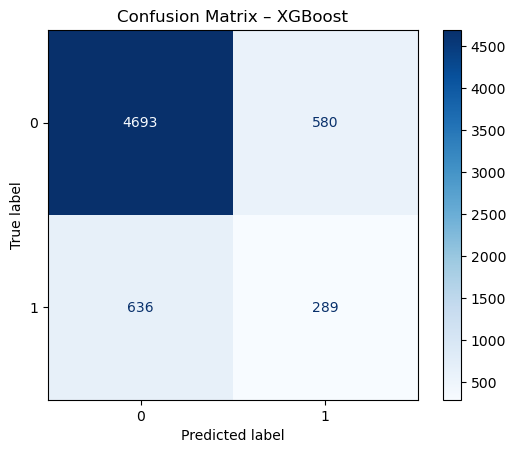

In [248]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – XGBoost")
plt.show()


**Hyperparameter Tuning**

In [249]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("Best Parameters:", xgb_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


**Evaluate TUNED XGBoost**

In [250]:
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= 0.25).astype(int)
print(classification_report(y_test, y_pred_best))



              precision    recall  f1-score   support

           0       0.88      0.88      0.88      5273
           1       0.32      0.33      0.33       925

    accuracy                           0.80      6198
   macro avg       0.60      0.60      0.60      6198
weighted avg       0.80      0.80      0.80      6198



**ROC Curve**

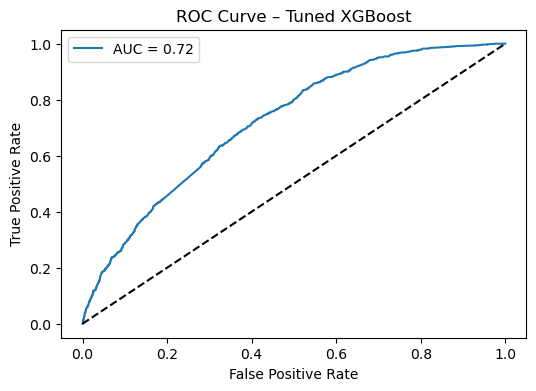

In [251]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned XGBoost")
plt.legend()
plt.show()


**Feature Importance**

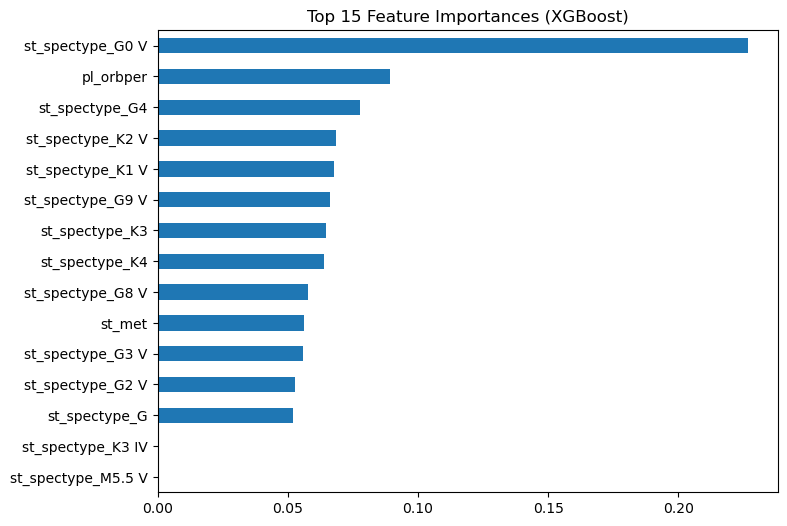

In [252]:
importances = best_xgb.feature_importances_
feature_names = X_train.columns   

feat_imp = pd.Series(importances, index=feature_names)

feat_imp.sort_values(ascending=False).head(15).plot(
    kind="barh",
    figsize=(8,6),
    title="Top 15 Feature Importances (XGBoost)"
)

plt.gca().invert_yaxis()
plt.show()



In [253]:
import os

os.makedirs("models", exist_ok=True)


In [254]:
import joblib
joblib.dump(best_xgb, "models/xgboost.pkl")


['models/xgboost.pkl']

**Habitability Scoring & Ranking**

In [255]:
X_full = df[X_train.columns]

df_ranked = df.copy()
df_ranked["habitability_probability"] = best_xgb.predict_proba(X_full)[:, 1]

df_ranked = df_ranked.sort_values(
    by="habitability_probability",
    ascending=False
)


In [256]:
os.makedirs("data/processed", exist_ok=True)

df_ranked.to_csv(
    "data/processed/habitability_ranked.csv",
    index=False
)

